In [3]:
print(sys.executable)

g:\Mi unidad\Tesis v1\mt\Scripts\python.exe


In [1]:
import os
import sys
import numpy as np
#from google.colab import drive

#drive.mount('/content/drive')

#garrar nuestra ruta de trabajo actual|

project_path = 'G:\\Mi unidad\\Tesis v1'
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)
sys.path.append(project_path)


#Elegimos la ruta donde trabajaremos con colab
BASE_FOLDER = os.path.join(project_path, 'Movement_clasify') #A)

#Rutas donde tenemos demás recursos
scripts_path = os.path.join(BASE_FOLDER, 'scripts')
note_path = os.path.join(BASE_FOLDER, 'notebooks')
resources_path = os.path.join(BASE_FOLDER, 'Recursos')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")
if os.path.exists(note_path): #
    if note_path not in sys.path:
        sys.path.append(note_path)
        print(f"✅ Path agregado: {note_path}")
else: print(f"No encontrse encontró la carpeta en {note_path}")
if os.path.exists(resources_path):#Donde están nuestros datos
    if resources_path not in sys.path:
        sys.path.append(resources_path)
        print(f"✅ Path agregado: {resources_path}")
else: print(f"No encontrse encontró la carpeta en {resources_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\notebooks
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\Recursos


In [2]:
#Comenzamos leyendo el dataset 

"""Recordatorio:

    "rest" -> 0
    "right_i" -> 1
    "left_i"->2
    "hands_i" -> 3
    "feet_i" -> 4
    "right_m" -> 5
    "left_m" -> 6
    "hands_m" -> 7
    "feet_m" -> 8
"""


data = np.load("Movement_clasify/Recursos/EEG_set50+8_dataset.npz", allow_pickle=True) #Modelo de finetunning, después usamos dataset más grande
pick = [0,1,2,5,6] #Las clases que queremos elegir, izquierda y derecha 

"""En caso de querer entrenar distintas clases:
pick = [0,3,4,7,8] Rest, Manos y pies 
pick = [0,1,2,5,6] Rest, Derecha e Izquierda
pick = [0,1,2,3,4,5,6,7,8] Todas las clases 
Si quieren, también pueden evaluar dos clases si quitan el cero, en caso de querer evaluar rest vs no rest usen la celda 5
"""
 

#Probamos nuestro nuevo objeto 

obj = dl.Selection(data, pick)



Undersampling: clase 0 recortada de 78510 a 20450 muestras.


In [18]:

X = obj.X
y = obj.y
sub = obj.sub
classes = obj.n_classes

#Probamos atributos nuevos 
#Elegir todos los sujetos menos el 7

mask_model = sub != 7

#Creamos el data para los sujetos a entrenar
X_modelo = X[mask_model]
y_modelo = y[mask_model]
sub_modelo = sub[mask_model]



print(np.unique(sub_modelo))

#Guardamos el sujeto 7 para testear después 

mask_fine = np.isin(sub, [7]) #El 7 fue el de mejor desempeño así que elijan siempre este 

#Elegimos solamente los datos del sujeto 100
X_fine = X[mask_fine]
y_fine = y[mask_fine]
sub_fine = sub[mask_fine]

#Undersample de 0 a max[1,2]}

X_under, y_under, sub_under = dl.undersample(X_fine, y_fine, sub_fine) #Ajustamos las clases para que no hayan sesgos

if len(np.unique(sub_under)) == 1:
        save = "modelos/v1/fine/EEG_finedata_7.npz"
        if not os.path.exists(os.path.dirname(save)):
            os.makedirs(os.path.dirname(save))
        np.savez(save, X=X_under, y=y_under, sub=sub_under)
        print("Se han guardado los datos del sujeto", sub_under[0], "en", save)
else: 
        print("Error: Se esperaba un solo sujeto, pero se encontraron", len(np.unique(sub_under)), "sujetos únicos:", np.unique(sub_under))
  



[  1   2   3   4   5   6   8   9  10  11  12  14  15  16  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 105]
Se han guardado los datos del sujeto 7 en modelos/v1/fine/EEG_finedata_7.npz


In [ ]:
"""RUEBA DE SLITEO, IGNORAR"""
split_obj, info = dl.split_eeg(X_modelo, y_modelo, sub_modelo, debug=True)

print("Sujetos de entrenamiento:", np.unique(split_obj.sub.train))
print("Sujetos de validación:", np.unique(split_obj.sub.val))
print("Sujetos de prueba:", np.unique(split_obj.sub.test))
print("Entrenamiento X:", split_obj.X.train.shape)
print("Validación X:", split_obj.X.val.shape)
print("Prueba X:", split_obj.X.test.shape)

print("Entrenamiento y:", split_obj.y.train.shape)
print("Validación y:", split_obj.y.val.shape)
print("Prueba y:", split_obj.y.test.shape)

print("Total de sujetos: ",len(np.unique(sub)))

Chao mamá
Tamaño de train vs test: (47949, 15, 160) (12479, 15, 160)
Modo split: subject
X_train: (40506, 15, 160) X_val: (7443, 15, 160) X_test: (12479, 15, 160)
Sujetos de entrenamiento: [  1   2   3   6   8   9  10  12  14  16  19  20  21  22  24  26  28  29
  30  31  32  34  35  38  39  40  42  43  45  50  51  52  53  56  57  58
  59  64  65  66  67  68  70  71  72  75  76  77  79  80  82  84  85  87
  89  90  91  94  95  97  99 100 101 102]
Sujetos de validación: [ 23  25  33  36  54  55  69  74  81  86  93 105]
Sujetos de prueba: [  4   5  11  15  18  27  37  44  46  47  48  49  60  73  78  88  92  96
  98 103]
Entrenamiento X: (40506, 15, 160)
Validación X: (7443, 15, 160)
Prueba X: (12479, 15, 160)
Entrenamiento y: (40506,)
Validación y: (7443,)
Prueba y: (12479,)
Total de sujetos:  97


In [8]:
modelo, history, mean, std, keras_split, info = dl.eeg_train(
    X_modelo, y_modelo, sub_modelo,
    epochs=100,
    debug=True,
    classes=classes
)

Tamaño de train vs test: (47949, 15, 160) (12479, 15, 160)
Modo split: subject
X_train: (40506, 15, 160) X_val: (7443, 15, 160) X_test: (12479, 15, 160)
Antes de normalizar: (40506, 15, 160) Después de normalizar: (40506, 15, 160) Después de ajustar para Keras: (40506, 15, 160, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
633/633 - 19s - 31ms/step - accuracy: 0.3990 - loss: 1.0741 - val_accuracy: 0.4356 - val_loss: 1.0567
Epoch 2/100
633/633 - 4s - 6ms/step - accuracy: 0.4416 - loss: 1.0483 - val_accuracy: 0.4646 - val_loss: 1.0687
Epoch 3/100
633/633 - 5s - 7ms/step - accuracy: 0.4493 - loss: 1.0396 - val_accuracy: 0.4799 - val_loss: 1.0449
Epoch 4/100
633/633 - 3s - 5ms/step - accuracy: 0.4589 - loss: 1.0339 - val_accuracy: 0.4690 - val_loss: 1.0600
Epoch 5/100
633/633 - 3s - 5ms/step - accuracy: 0.4597 - loss: 1.0313 - val_accuracy: 0.4622 - val_loss: 1.0418
Epoch 6/100
633/633 - 3s - 5ms/step - accuracy: 0.4662 - loss: 1.0265 - val_accuracy: 0.4694 - val_loss: 1.0392
Epoch 7/100
633/633 - 5s - 7ms/step - accuracy: 0.4659 - loss: 1.0246 - val_accuracy: 0.4719 - val_loss: 1.0464
Epoch 8/100
633/633 - 3s - 6ms/step - accuracy: 0.4703 - loss: 1.0229 - val_accuracy: 0.4536 - val_loss: 1.0582
Epoch 9/100
633/633 - 3s - 5ms/step - accuracy: 0.4766 - loss: 1.0199 - val_accuracy: 0.4704 - val_los

390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

=== Evaluación EEGnet finetunned ===
Clases (índice -> nombre):
  0: rest
  1: izquierda
  2: derecha

Matriz de confusión (conteos):
[[1123 2060  951]
 [ 335 2872  938]
 [ 420 2344 1436]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.60      0.27      0.37      4134
   izquierda       0.39      0.69      0.50      4145
     derecha       0.43      0.34      0.38      4200

    accuracy                           0.44     12479
   macro avg       0.47      0.44      0.42     12479
weighted avg       0.47      0.44      0.42     12479



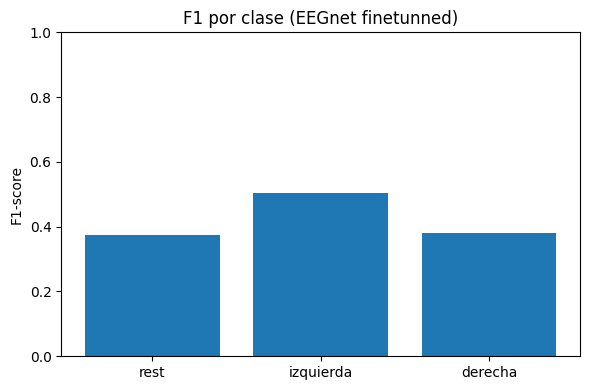

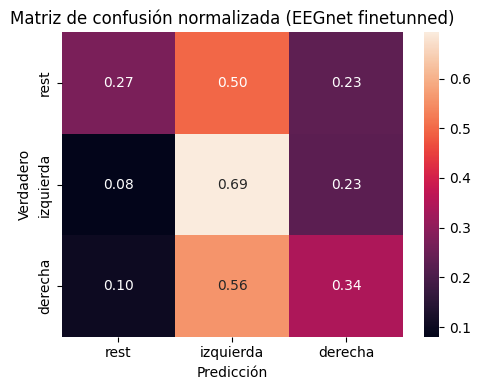

In [10]:
# Después de entrenar:
X_test = keras_split.X.test
y_test = keras_split.y.test
y_prob = modelo.predict(X_test)

# Si tus etiquetas ya están remapeadas a 0..C-1 por pick,
# puedes pasar nombres de clase en ese mismo orden:
nombres = ["rest","izquierda", "derecha"]  # ejemplo para 3 clases

resultados = dl.evaluar_modelo_multiclase(
    y_true=y_test,
    y_prob=y_prob,
    class_names=nombres,          # o None si no quieres nombres
    title_prefix="EEGnet finetunned"
)

In [ ]:
#Guardamos el modelo y sus parámetros de normalización

save = r"modelos/v3/EEGnet_general_01256.keras"
#asegurarnos de que exista la carpeta 
if not os.path.exists(os.path.dirname(save)):
    os.makedirs(os.path.dirname(save))
modelo.save(save)
name = r""
np.savez(name, mean=mean, std=std)


In [3]:
#Cargar modelo en caso de que ya tenegamos uno guardado
from tensorflow.keras.models import load_model
modelo = load_model(r"modelos/v3/EEGnet_general_01256.keras")

datos = np.load("modelos/v3/EEGnet_general_01256.npz", allow_pickle=True)

mean = datos['mean']
std = datos['std']

In [6]:
#Elegir al sujeto de finetunning
mask_fine = np.isin(sub, [7]) #El 7 fue el de mejor desempeño así que elijan siempre este 

#Elegimos solamente los datos del sujeto 100
X_fine = X[mask_fine]
y_fine = y[mask_fine]
sub_fine = sub[mask_fine]

#Undersample de 0 a max[1,2]}

X_under, y_under, sub_under = dl.undersample(X_fine, y_fine, sub_fine) #Ajustamos las clases para que no hayan sesgos

print(len(np.unique(sub_fine)))
print(X_under.shape, y_under.shape, sub_under.shape)

print(np.unique(y_under, return_counts=True))
print(classes)

1
(667, 15, 160) (667,) (667,)
(array([0, 1, 2]), array([217, 220, 230]))
3


In [7]:
modelo_fined, historial, mean_fine, std_fine, X_list_fine, y_list_fine = dl.eeg_fine(modelo, X_under, y_under, sub_under, debug=True, epochs=150)


Tamaño del train: (533, 15, 160) Tamaño del val: (67, 15, 160) Tamaño del test: (67, 15, 160)
Antes de normalizar: (533, 15, 160) Después de ajustar para Keras: (533, 15, 160, 1)
Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 415ms/step - accuracy: 0.6050 - loss: 0.8915 - val_accuracy: 0.6119 - val_loss: 0.8899
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6185 - loss: 0.9031 - val_accuracy: 0.6119 - val_loss: 0.8820
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6506 - loss: 0.8607 - val_accuracy: 0.6269 - val_loss: 0.8745
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6490 - loss: 0.8537 - val_accuracy: 0.6567 - val_loss: 0.8690
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6894 - loss: 0.8432 - val_accuracy: 0.6418 - val_loss: 0.8637
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6609 - loss: 0.8339 - val_accuracy: 0.6418 - val_loss: 0.8588
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step -

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step

=== Evaluación EEGnet finetunned ===
Clases (índice -> nombre):
  0: rest
  1: izquierda
  2: derecha

Matriz de confusión (conteos):
[[12  4  6]
 [ 0 20  2]
 [ 2  0 21]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.86      0.55      0.67        22
   izquierda       0.83      0.91      0.87        22
     derecha       0.72      0.91      0.81        23

    accuracy                           0.79        67
   macro avg       0.80      0.79      0.78        67
weighted avg       0.80      0.79      0.78        67



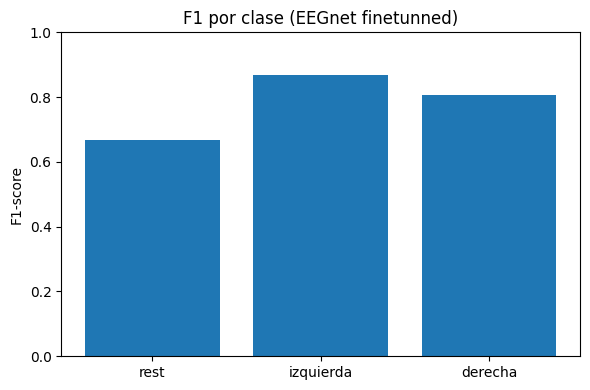

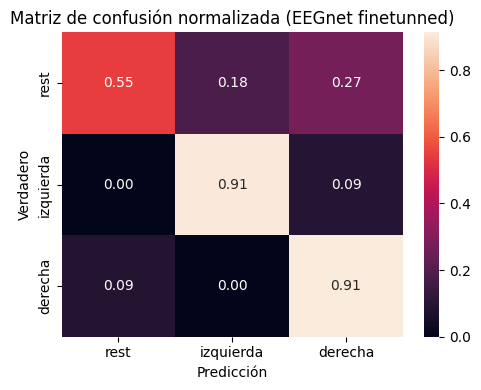

In [8]:
# Después de entrenar:
X_test = X_list_fine[2]
y_test = y_list_fine[2]
y_prob = modelo_fined.predict(X_test)

# Si tus etiquetas ya están remapeadas a 0..C-1 por pick,
# puedes pasar nombres de clase en ese mismo orden:
nombres = ["rest","izquierda", "derecha"]  # ejemplo para 3 clases

resultados = dl.evaluar_modelo_multiclase(
    y_true=y_test,
    y_prob=y_prob,
    class_names=nombres,          # o None si no quieres nombres
    title_prefix="EEGnet finetunned"
)